# Solar Notebook

In [ ]:
import os

import numpy as np
import pandas as pd
from dotenv import load_dotenv
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from suse.solar.nrel_api import download_solar_data
from suse.solar.solar_calc import compute_environmental_params, compute_panel_radiation
from suse.solar.panel_calc import compute_panel_e
pio.templates.default = "simple_white"
pd.options.plotting.backend = "plotly"

load_dotenv()
# NREL_KEY = dotenv_values("../.env")['NREL_API_KEY']

# For this to work, you need to make an .env file in the root folder of this repo with your nrel api key:
# NREL_API_KEY=<your_key>
# EMAIL=<your_email>
NREL_KEY = os.environ.get("NREL_API_KEY")
EMAIL = os.environ.get("EMAIL")

DATA_DIR = "../data/solar"

# Adjust the style of plotly plot
pio.templates["suse"] = go.layout.Template(
    layout=go.Layout(
        font=dict(size=16),
        # title=dict(font=dict(size=18))
        legend=dict(orientation="h", xanchor="right", yanchor="bottom", x=1, y=1.02,title=None),
        xaxis=dict(linewidth=3,tickwidth=3),
        yaxis=dict(linewidth=3,tickwidth=3),
    ),
    data=dict(
        scatter=[dict(line=dict(width=5),marker=dict(size=9))]
    )
)

pio.templates.default = "simple_white+suse"

In [12]:
# Input options  lat
# lat = 34.59593337169398 #34.125448  
# lon = -117.11428489257814 #-118.038843 
lat,lon = (34.59593337169398, -117.11428489257814)
# lat,lon = (34.41110657027859, -116.85382470703124)
year = 2022
# solar_file = f'{DATA_DIR}/solar_data.parquet'

slope = lat  # or 35
grd_reflect = 0.2
geometry = f"POINT ({lon} {lat})"
df = download_solar_data(year=year, wkt=geometry, email=EMAIL, api_key=NREL_KEY, show_url=False)
df = compute_environmental_params(df, lon=lon, lat=lat)
df = compute_panel_radiation(df, lat=lat, slope=slope, grd_reflect=df["Surface Albedo"])
df = compute_panel_e(
    df,
    PV_n_panels=1502406*16,
    NOCT=45.7,
    beta=0.0045,
    module_rated_W=250,
    module_area=1.66,
    grid_price=0.125,
    install_cost_per_W=1.3
)


Total Monthly Radiation:
Fixed Panel: 2501998 Wh/m2

System rated power: 6,009,624.0 kW
Total install cost: $7,812,511,200.0
Total area: 39903903.36 m^2
Total PV Electricity: 12,343,578,726 kWh/yr
Total Energy Savings: $1,542,947,340.73 
Avg Efficiency: 0.136


In [13]:
def plot_electric(df,type='bar'):
    df.index = df.index.map(lambda t: t.replace(day=1))
    fig = make_subplots(specs=[[{"secondary_y": True}]])
    plot_func = go.Bar if type=='bar' else go.Scatter
    fig.add_traces(plot_func(x=df.index,y=df['PV_W_e']/1e12,name="PV Electricity"))
    fig.update_traces(name='PV Electricity', showlegend = True)
    fig.add_trace(go.Scatter(x=df.index,y=df['PV_n']*100,name='Efficiency'),secondary_y=True)
    fig.update_layout(
        yaxis_title="Total Electricity [TWh]",
        yaxis2_title="Avg Efficiency [%]",
        title='Solar Generation and Efficiency',
        xaxis_tickformat='%b'
    )
    # fig.update_xaxes(type='category')

    fig.show("png")

C:\Software\Anaconda\Temp\ipykernel_33696\3311728564.py:1: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



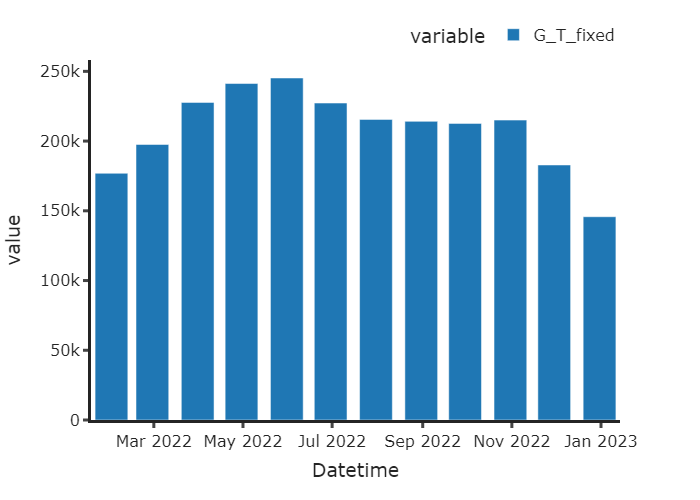

In [14]:
df['G_T_fixed'].resample('M').sum().plot.bar().show('png')

C:\Software\Anaconda\Temp\ipykernel_33696\2492418798.py:1: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



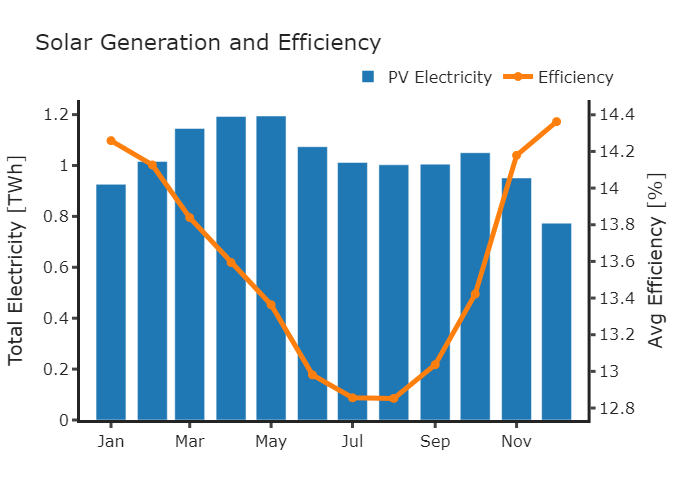

In [15]:

plot_electric(df[['PV_W_e','PV_n']].resample('M').agg({'PV_W_e':'sum','PV_n':'mean'}))

# Sensitivity Analysis with California Energy Commission Data

In [16]:
cec_df = pd.read_excel('https://solarequipment.energy.ca.gov/Home/DownloadtoExcel?filename=PVModuleList',skiprows=list(range(0,16))+[17])
cec_df.columns

Index(['Manufacturer', 'Model Number', 'Description', 'Safety Certification',
       'Nameplate Pmax', 'PTC', 'Notes',
       'Design Qualification Certification\n(Optional Submission)',
       'Performance Evaluation (Optional Submission)', 'Family', 'Technology',
       'A_c', 'N_s', 'N_p', 'BIPV', 'Nameplate Isc', 'Nameplate Voc',
       'Nameplate Ipmax', 'Nameplate Vpmax', 'Average NOCT', 'γPmax', 'αIsc',
       'βVoc', 'αIpmax', 'βVpmax', 'IPmax, low', 'VPmax, low', 'IPmax, NOCT',
       'VPmax, NOCT', 'Mounting', 'Type', 'Short Side', 'Long Side',
       'Geometric Multiplier', 'P2/Pref', 'CEC Listing Date', 'Last Update'],
      dtype='object')

In [17]:
cec_df[['Nameplate Pmax','A_c','Average NOCT','γPmax']].describe()

,Nameplate Pmax,A_c,Average NOCT,γPmax
count,22149.000000,22149.000000,22149.000000,22149.000000
mean,368.411746,1.945482,45.577976,-0.385609
std,111.049819,0.385755,1.730626,0.058931
min,17.500000,0.139000,40.000000,-0.898343
25%,290.000000,1.640000,44.400000,-0.432000
50%,355.000000,1.940000,45.600000,-0.377460
75%,430.000000,2.100000,46.500000,-0.343400
max,740.000000,5.720000,62.900000,-0.030700


In [ ]:
noct_sen_df = {n:compute_panel_e(
    df,
    PV_n_panels=1502406*16,
    NOCT=n,
    beta=0.0045,
    module_rated_W=250,
    module_area=1.66,
    grid_price=0.125,
    install_cost_per_W=1.3,
    verbose=False
)[['PV_W_e','PV_n']].resample('Y').agg({'PV_W_e':'sum','PV_n':'mean'}) for n in np.linspace(40,50,10)}

In [20]:
beta_sen_df = {b:compute_panel_e(
    df,
    PV_n_panels=1502406*16,
    NOCT=45.7,
    beta=b,
    module_rated_W=250,
    module_area=1.66,
    grid_price=0.125,
    install_cost_per_W=1.3,
    verbose=False
)[['PV_W_e','PV_n']].resample('YE').agg({'PV_W_e':'sum','PV_n':'mean'}) for b in np.linspace(0.00030700,0.00898343,10)}


In [21]:
def plot_sen(df,type='bar',xlabel=None,title=None):
    # df.index = df.index.map(lambda t: t.replace(day=1))
    fig = make_subplots(specs=[[{"secondary_y": True}]])
    plot_func = go.Bar if type=='bar' else go.Scatter
    fig.add_traces(plot_func(x=df.index,y=df['PV_W_e']/1e12,name="PV Electricity"))
    fig.update_traces(name='PV Electricity', showlegend = True)
    fig.add_trace(go.Scatter(x=df.index,y=df['PV_n']*100,name='Efficiency'),secondary_y=True)
    fig.update_layout(
        yaxis_title="Annual Total Electricity [TWh]",
        yaxis2_title="Avg Efficiency [%]",
        title=title,
        xaxis_tickformat='%b',
        xaxis_title=xlabel,
    )
    # fig.update_xaxes(type='category')

    fig.show("png")
    return fig

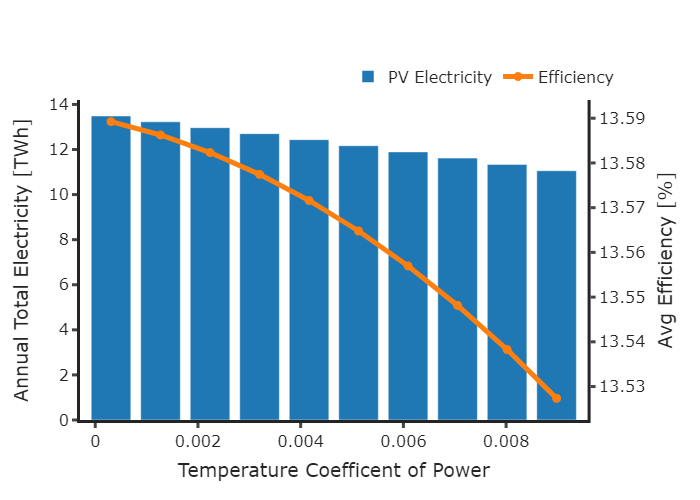

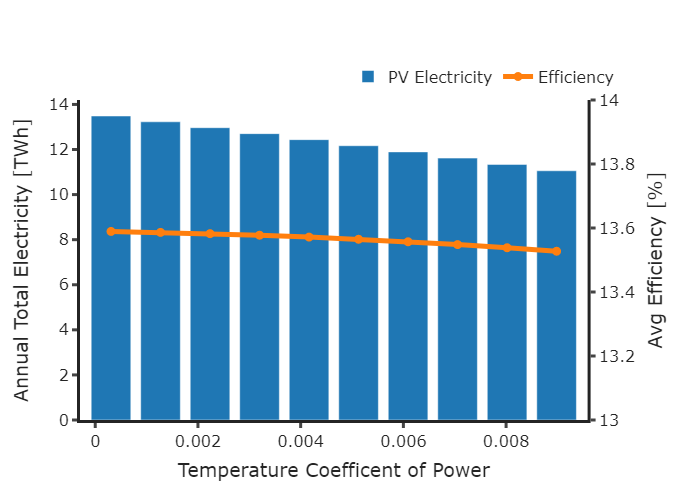

In [22]:
fig = plot_sen(pd.concat(beta_sen_df).reset_index().set_index('level_0')[['PV_W_e','PV_n']],xlabel='Temperature Coefficent of Power',title=None)
fig.update_layout(yaxis2_range=[13,14]).show('png')

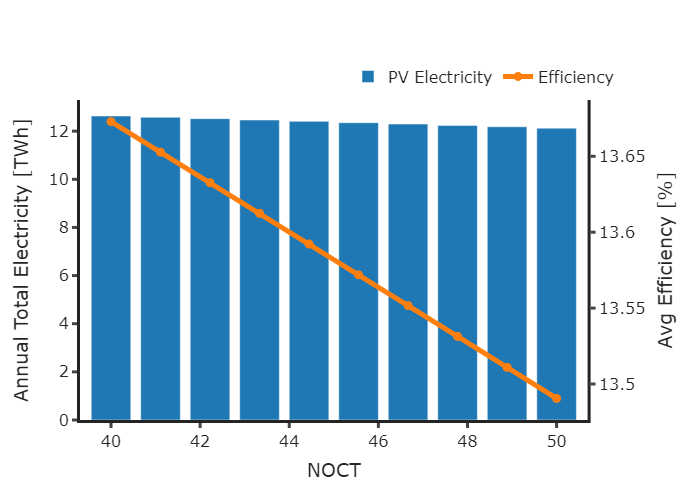

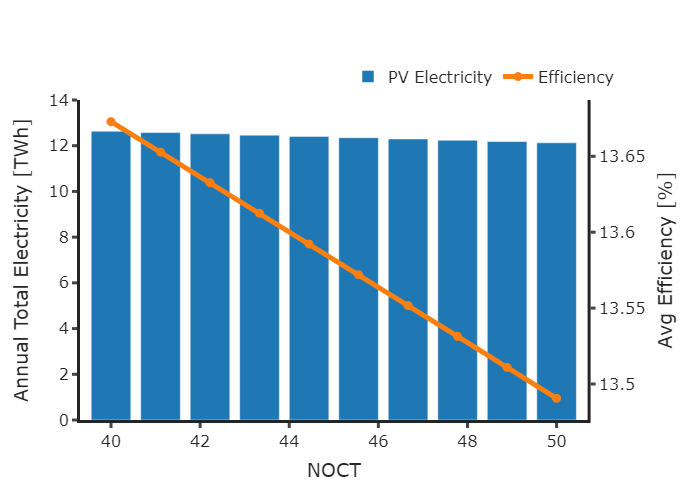

In [23]:
fig = plot_sen(pd.concat(noct_sen_df).reset_index().set_index('level_0')[['PV_W_e','PV_n']],xlabel='NOCT',title=None)
fig.update_layout(yaxis_range=[0,14]).show('png')

In [24]:
df[['PV_W_e','PV_n']].resample('M').agg({'PV_W_e':'sum','PV_n':'mean'})

C:\Software\Anaconda\Temp\ipykernel_33696\2718627555.py:1: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



,PV_W_e,PV_n
Datetime,,
2022-01-31,9.259809e+11,0.142591
2022-02-28,1.016179e+12,0.141263
2022-03-31,1.145691e+12,0.138389
2022-04-30,1.192867e+12,0.135939
2022-05-31,1.194519e+12,0.133633
2022-06-30,1.073867e+12,0.129809
2022-07-31,1.011797e+12,0.128559
2022-08-31,1.002670e+12,0.128527
2022-09-30,1.005313e+12,0.130364


In [ ]:
# # geometry = "POLYGON ((-118.262329 33.628342, -117.751465 33.628342, -117.751465 34.077687, -118.262329 34.077687, -118.262329 33.628342))"
# try:
#     raise ValueError
#     Path(DATA_DIR).mkdir(parents=True, exist_ok=True)
#     df = pd.read_parquet(solar_file)
# except:
#     df.to_parquet(solar_file)

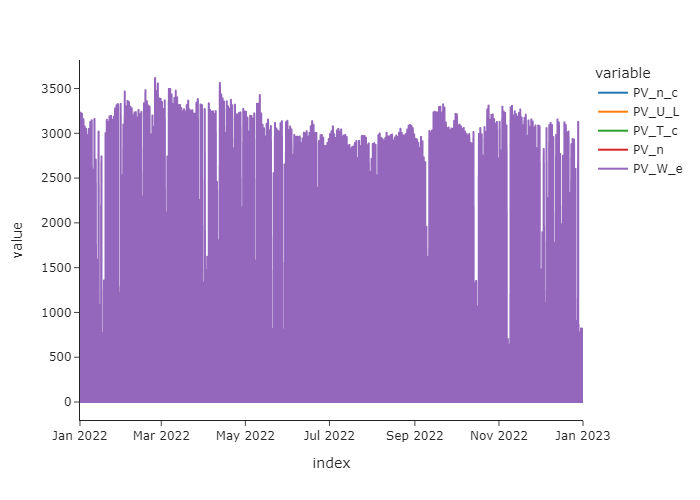

In [166]:
df.plot(y=["PV_n_c", "PV_U_L", "PV_T_c", "PV_n", "PV_W_e"]).show('png')

In [ ]:
df.plot(y="G_T_fixed")

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_traces(go.Scatter(x=df["Datetime"], y=df["PV_W_e"], name="PV Electricity"))
fig.update_traces(name="PV Electricity", showlegend=True)
fig.add_trace(go.Scatter(x=df["Datetime"], y=df["PV_n"], name="Efficiency"), secondary_y=True)
fig.update_layout(
    yaxis_title="Electricity [W]",
    yaxis2_title="Efficiency",
)

fig.show("vscode")

In [ ]:
df.plot(x="Datetime", y=["GHI (W/m^2)", "DNI (W/m^2)", "G_b", "G_d"])

In [ ]:
# https://www.nrel.gov/docs/fy25osti/92257.pdf

# Page 28 pricing for industry